In [89]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")


# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [91]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [92]:
# Total NAs for all features & response 
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [93]:
# Distribution of response values 
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [96]:
# Fill NA values with column median 
df_clean = df.fillna(df.median())

# Check to see if there are NAs in columns
df_clean.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [111]:
# Seperate Xs and y 
features = [c for c in df.columns if c != 'Potability']
X = df_clean[features]
y = df_clean['Potability']

In [112]:
# 30/70 training test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    stratify=y, 
                                                    random_state=42)

In [113]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [142]:
# Initalize 
dt_unpruned = DecisionTreeClassifier(random_state=42)
# Fit 
dt_unpruned.fit(X_train, y_train)

# Evaluate 
tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

# Print statements
print(f"Best max_depth (5-fold CV): {tree_depth}")
print(f"Training accuracy:    {dt_unpruned_acc_train:.3f}")
print(f"Test accuracy:    {dt_unpruned_acc_test:.3f}")

Best max_depth (5-fold CV): 33
Training accuracy:    1.000
Test accuracy:    0.581


In [115]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The test accuracy is half of the training accuracy. This means the training accuracy is excellent but the model is not genalizing well to the test data set. The is no error in the training set, but lots of error in the test data. The model is overfitting. The model is working too hard to find patterns in the training data, and thus picking up on noise and patterns from random chance instead of true proporties of the dataset. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

In [134]:
# Range of 1 to 20 
max_depth = list(range(1,21))

# Empty vector 
dt_cv_acc= [] 

# Compute mean CV accuracy 
for n in max_depth: 
    dt_cv = DecisionTreeClassifier(max_depth=n)
    scores = cross_val_score(dt_cv, X_train, y_train, cv=5, scoring='accuracy')
    dt_cv_acc.append(scores.mean())

# Optimal depth 
dt_cv_means = np.array(dt_cv_acc)
optimal_depth   = max_depth[np.argmax(dt_cv_acc)]

# Print statement 
print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {dt_cv_means.max():.3f})")


Best max_depth (5-fold CV): 7  (CV accuracy: 0.641)


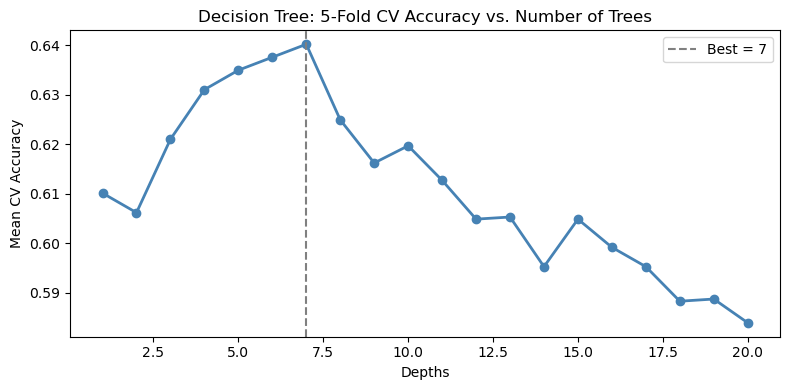

In [127]:
# Plot CV accuracy against the 20 diff depth 
plt.figure(figsize=(8, 4))
plt.plot(max_depth, dt_cv_acc, marker='o', color='steelblue', linewidth=2)
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best = {optimal_depth}')
plt.xlabel('Depths')
plt.ylabel('Mean CV Accuracy')
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

In [135]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

I found a optimal depth to be 7 meaning the tree is best (not under or overfitting) when the tree extends 7 leafs deep. At depth of 7, the model is complex enough to capture the logic of the dataset but not too complex to where it lose its ability to generalize.  

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [143]:
# Refit decision tree with optimal depth 
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

# Fit model 
dt_opt.fit(X_train, y_train)

# Evaluate test set 
acc_dt    = accuracy_score(y_test, dt_opt.predict(X_test))

# Print statement
print(f"Test accuracy:    {acc_dt:.3f}")

Test accuracy:    0.646


In [138]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

The test accuracy improved by 0.065. Without limiting the depth of the tree, the decision tree will create a fully grown tree with leaf nodes for all training data classfications, resulting in 100% accuracy and lots of overfitting. When the tree is limited to the opitimal depth, the decision tree reflects the data's true patterns more, not the random noise, resulting in a better test accuracy score. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

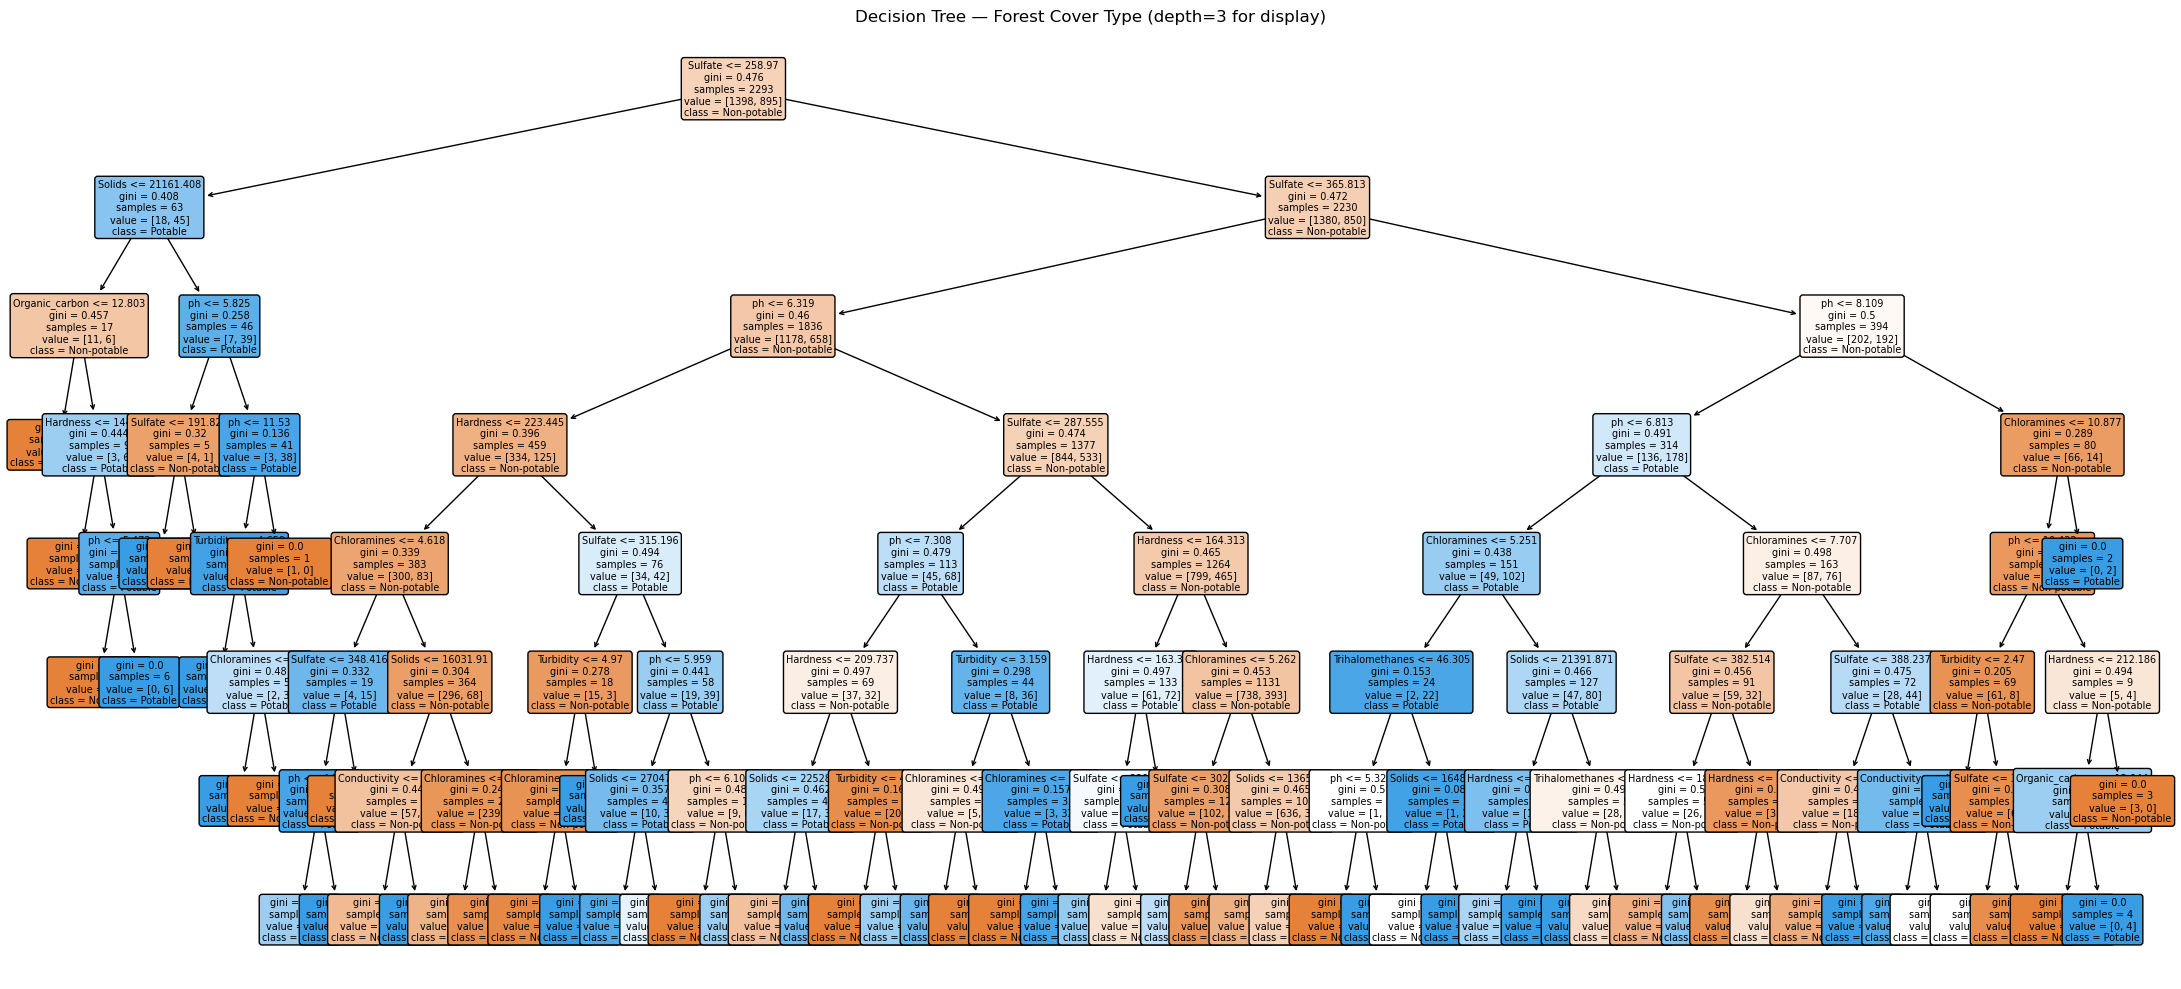

In [ ]:
plt.figure(figsize=(22, 10))
class_names = ['Non-potable', 'Potable']

plot_tree(dt_opt, 
          feature_names=features, 
          class_names=class_names, 
          filled = True, 
          rounded = True, 
          fontsize=7)

plt.title('Decision Tree — Forest Cover Type (depth=3 for display)')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

Sulfate is the first root split, using a threshold of 258.97 (mg/L). This shows that sulfate levels are an important predictor that heavily dicate drinkability. 

At the root, the Gini impurity is 0.476. For the second splits, the Gini impurity levels are 0.408 and 0.472. This means the the classes are quite mixed at the top of the decision tree. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [149]:
# Initalize
rf = RandomForestClassifier(n_estimators=200, random_state=42)
# Fit 
rf.fit(X_train, y_train)
# Evaluate 
acc_rf    = accuracy_score(y_test, rf.predict(X_test))

# Print statement
print(f"Decision Tree Test accuracy:    {acc_dt:.3f}")
print(f"Random Forest Test accuracy:    {acc_rf:.3f}")

Decision Tree Test accuracy:    0.646
Random Forest Test accuracy:    0.664


In [148]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

Random forest model is performing better with about a 0.02 higher accuracy score. Random forest decorrelates the tree by drawing random subsets of features at each split, reducing the variance and increasing accuracy.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

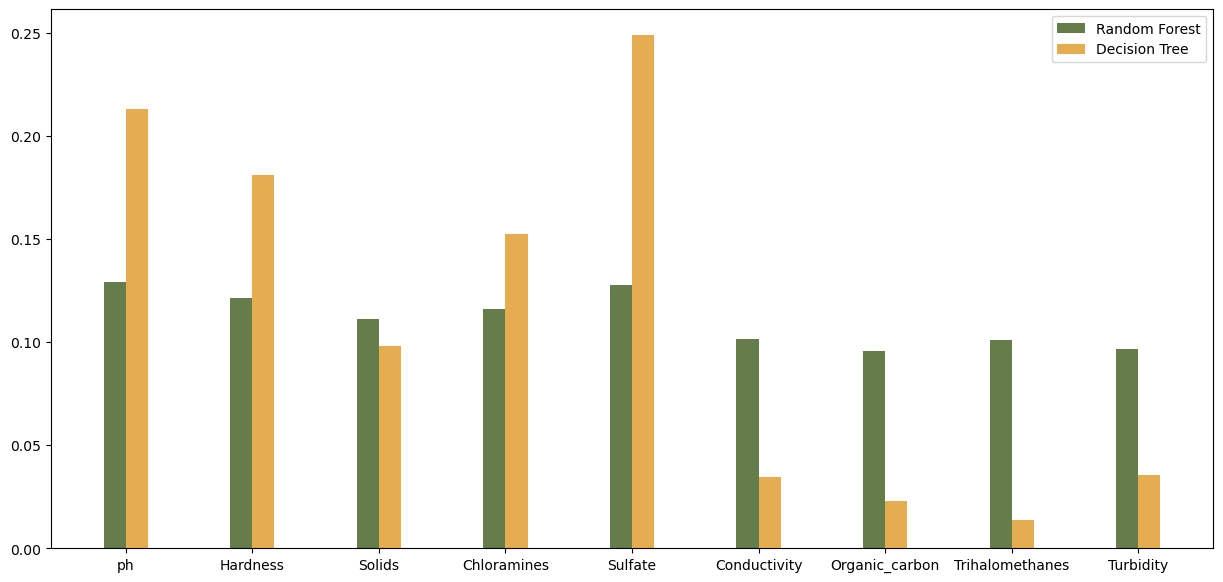

In [ ]:
# Plot a cluster bar chart
x = np.arange(len(features)) * 2
bar_width = 0.35

fig, ax = plt.subplots(1, 1, figsize=(15, 7))

ax.bar(x - bar_width/2, rf.feature_importances_, bar_width, label = 'Random Forest', color = "#647D4BFF")
ax.bar(x + bar_width/2, dt_opt.feature_importances_, bar_width, label = "Decision Tree", color = "#E5AD4FFF")

ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
plt.show()



> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

Random forest shows all features being about equally important with pH, sulfate, and hardness having a slightly higher importance than the rest. On the other hand, the decision tree shows sulfate being the most important predictor by far, followed by pH and hardness. Sulfate appears the most important in predictiong portability which makes physical sense as sulfate naturally dissolutions from minials into water bodies and is within the Secondary Maximum Contaminant Level (SMCL) guildlines. PH and hardness are also very important when predicting potability which also make sense because extreme levels in both cases pose potability risks. 

In random forest, each tree is trained on a random bootstap sample of the data which ensures one dominate trait (sulfate) is not dictating the outcome of every decision. Random forest aggregates the predection of many trees which reduces overfitting and increases the generalize ability of the model. Therefore, the results from random forest are be more reiable than the single tree.  

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

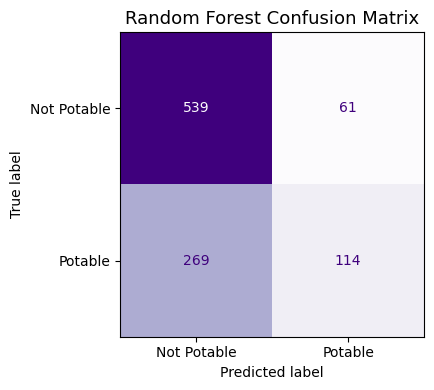

In [184]:
# Create RF Confusion matrix 
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Not Potable', 'Potable'])

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar = False, cmap = "Purples")
ax.set_ylim(len(["Not Potable", "Potable"]) - 0.5, -0.5)
ax.set_title('Random Forest Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

True positives = 114. Number of potable classifications that were predicted as potable. 
True negatives = 539. Number of non-potable classifications that were predicted as non-potable. 
False positives = 61. Number of non-potable classifications that were predicted as potable. 
False negatives = 269. Number of potable classifications that were predicted as non-potable. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [179]:
# Create table to compare test accuracies
models_acc = pd.DataFrame({
    'Model': ['Unpruned Decision Tree', 'Tuned Decision Tree', 'Random forest'],
    'Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf]
})

print(models_acc.to_string(index=False))

                 Model  Accuracy
Unpruned Decision Tree  0.580875
   Tuned Decision Tree  0.645982
         Random forest  0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


Random forest achieved the highest test accuracy. 
Pruning the decision tree improved the accuracy score by 0.065. Without limiting the decision tree's depth, the tree fully grows to match the training data causing major overfitting. Therefore, pruning the decision tree's depth is neccessary to minimize overfitting. 

---

Run the cell below to receive credit for autograded questions. 

In [180]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError